# A3 · Attention Signals and Event Studies

*Sentiment & Alternative Data track*

When something important happens to a company, trading volume explodes. This notebook uses volume spikes as a free, real-data proxy for "news days", and introduces the event study: the standard method for measuring how prices react to any kind of event, including the news and sentiment signals this track is about.

## 1. Motivation

The team wants to know whether positive news about a company is followed by further price gains in the days afterwards. Answering that needs two things: a list of news events with dates, and a method for measuring the "normal" price move so the event's effect can be separated from the market's. We don't have a news archive yet. But we do have something closely related: days when a stock trades several times its usual volume almost always coincide with news (earnings, deals, scandals). They are a good stand-in for building and testing the method.

## 2. Intuition

**Attention.** Investors can't follow every stock. When a stock suddenly grabs attention, through news or a big move, many people trade it at once. Two competing stories predict what happens next:

- **Under-reaction:** investors absorb the news slowly, so the price keeps drifting in the direction of the news for days or weeks.
- **Over-reaction:** the attention burst pushes the price too far, and it partly reverses.

**Event study.** To tell these apart we line up all events on a common clock: day 0 is the event, day 1 the next trading day, and so on. Then we average the stock's **abnormal** return (its return minus what the market would have predicted) across hundreds of events. Random noise averages out. What remains is the typical reaction to this kind of event.

## 3. The math

**Event definition.** Stock $i$ has a **volume shock** on day $t$ if its dollar volume is at least three times its average over the previous 63 days:
$$
\frac{DV_{i,t}}{\frac{1}{63}\sum_{k=1}^{63} DV_{i,t-k}} \ge 3 .
$$
To avoid counting one episode many times, events for the same stock must be at least 21 trading days apart.

**Abnormal returns (market model).** Estimate each stock's beta to the market (P4) from data before the event, then
$$
AR_{i,t} = R_{i,t} - \hat\beta_i\, R_{m,t}.
$$
The beta uses a 252-day window ending 11 days before the event, so the event itself can't affect it.

**Cumulative abnormal return (CAR)** from day 1 to day $\tau$ after the event, averaged over the $n$ events in a group:
$$
\overline{CAR}(\tau) = \frac{1}{n}\sum_{e=1}^{n} \sum_{k=1}^{\tau} AR_{i_e,\,t_e + k} .
$$
Starting at day 1 is deliberate: day 0's move is the event itself, which you can't trade. Only what happens *after* day 0 is tradable.

**Is it significant?** The standard error of $\overline{CAR}(\tau)$ is the cross-event standard deviation of CARs divided by $\sqrt{n}$. As a rule of thumb, $|t| = |\overline{CAR}| / SE > 2$.

We split events by the **sign of the day-0 abnormal return**: up-shocks (likely good news) and down-shocks (likely bad news).

## 4. Code it

### 4.1 Setup and abnormal returns

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)
volume = pd.read_csv("../data/volume.csv", index_col="date", parse_dates=True)
meta = pd.read_csv("../data/meta.csv")

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

stocks = meta.loc[meta.asset_type == "stock", "ticker"]
R = prices[stocks].pct_change()
Rm = prices["SPY"].pct_change()

# Rolling market beta over 252 days, lagged 11 days so the event window can't influence it
beta = R.rolling(252).cov(Rm).div(Rm.rolling(252).var(), axis=0).shift(11)
AR = R - beta.mul(Rm, axis=0)                        # AR_it = R_it - beta_i R_mt

### 4.2 Find the events

In [2]:
dollar_vol = prices[stocks] * volume[stocks]
shock_ratio = dollar_vol / dollar_vol.rolling(63).mean().shift(1)    # today vs. the previous 63 days

events = []
for t in stocks:
    last_i = -10**9
    for d in shock_ratio.index[shock_ratio[t] >= 3]:
        i = prices.index.get_loc(d)
        if i - last_i >= 21:                         # at least 21 trading days since the last event
            events.append((t, d, i))
            last_i = i

# Keep events with a full window: 5 days before to 20 days after, and a valid beta
window = range(-5, 21)
rows = []
for t, d, i in events:
    if i + 20 >= len(prices) or i < 5:
        continue
    path = AR[t].iloc[i - 5:i + 21].values
    if not np.isnan(path).any():
        rows.append({"ticker": t, "date": d, "ar0": path[5], "path": path})
ev = pd.DataFrame(rows)

print(f"{len(ev)} volume-shock events across {ev['ticker'].nunique()} stocks")
print(f"Up-shocks: {(ev['ar0'] > 0).sum()}, down-shocks: {(ev['ar0'] < 0).sum()}")
print(f"Average |abnormal return| on the event day: {ev['ar0'].abs().mean():.1%}")
print("\nLargest events:")
print(ev.reindex(ev["ar0"].abs().sort_values(ascending=False).index)[["ticker", "date", "ar0"]]
      .head(5).assign(ar0=lambda d: d["ar0"].map("{:+.1%}".format)).to_string(index=False))

1069 volume-shock events across 43 stocks
Up-shocks: 549, down-shocks: 520
Average |abnormal return| on the event day: 4.7%

Largest events:
ticker       date    ar0
  NFLX 2013-01-24 +42.2%
  NFLX 2022-04-20 -35.0%
  NVDA 2016-11-11 +30.1%
  NFLX 2013-04-23 +23.4%
  SBUX 2024-08-13 +23.3%


About 1,070 events, roughly half up and half down, with an average day-0 abnormal move of almost 5%. These are big news days. The largest ones are recognisable: Netflix's subscriber-growth surprises in 2013 and its subscriber *loss* in April 2022, NVIDIA's data-centre breakout in late 2016, and Starbucks' CEO change in August 2024. The volume filter finds real news without reading a single headline.

### 4.3 The event study

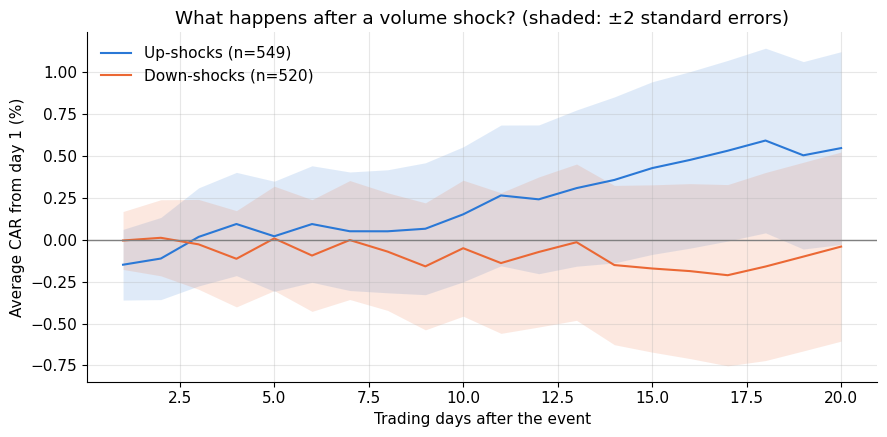

,CAR day 1-5,CAR day 1-20,t-stat (day 20)
Up-shocks,+0.02%,+0.55%,1.90
Down-shocks,+0.01%,-0.04%,-0.15


In [3]:
def car_from_day1(group):
    paths = np.vstack(group["path"])           # events x 26 days (day -5 ... day +20)
    after = paths[:, 6:]                       # day +1 ... +20
    car = after.cumsum(axis=1)                 # CAR(tau) for each event
    return car.mean(axis=0), car.std(axis=0) / np.sqrt(len(car))

fig, ax = plt.subplots()
taus = np.arange(1, 21)
table = {}
for name, grp, c in [("Up-shocks", ev[ev["ar0"] > 0], COLORS[0]), ("Down-shocks", ev[ev["ar0"] < 0], COLORS[1])]:
    mean, se = car_from_day1(grp)
    ax.plot(taus, mean * 100, color=c, label=f"{name} (n={len(grp)})")
    ax.fill_between(taus, (mean - 2 * se) * 100, (mean + 2 * se) * 100, color=c, alpha=0.15, linewidth=0)
    table[name] = {"CAR day 1-5": mean[4], "CAR day 1-20": mean[19], "t-stat (day 20)": mean[19] / se[19]}
ax.axhline(0, color="grey", linewidth=1)
ax.set_xlabel("Trading days after the event")
ax.set_ylabel("Average CAR from day 1 (%)")
ax.set_title("What happens after a volume shock? (shaded: ±2 standard errors)")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

pd.DataFrame(table).T.assign(**{"CAR day 1-5": lambda d: d["CAR day 1-5"].map("{:+.2%}".format),
                               "CAR day 1-20": lambda d: d["CAR day 1-20"].map("{:+.2%}".format),
                               "t-stat (day 20)": lambda d: d["t-stat (day 20)"].round(2)})

- **Down-shocks: no drift at all.** After a bad-news day, these large stocks' abnormal returns over the next month average almost exactly zero. The market priced the bad news in on day 0.
- **Up-shocks: a small continuation.** About +0.55% over the next 20 days, with a t-statistic of 1.9: suggestive but not quite significant. This fits the under-reaction story and the "high-volume return premium" found in academic studies, where stocks with unusual attention tend to do slightly better afterwards.
- **Practically, it is small.** 0.55% over a month, for a strategy that must trade within a day of each event, is roughly the size of a round-trip trading cost in a volatile stock right after news (notebook 5).

### 4.4 Before the event

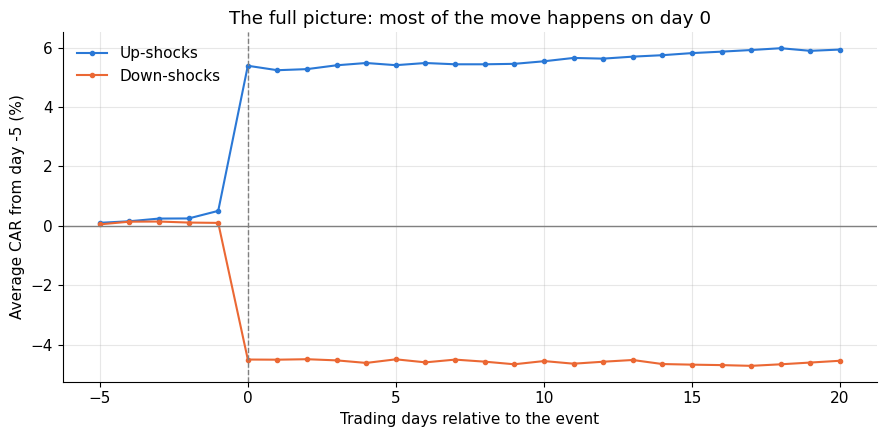

In [4]:
fig, ax = plt.subplots()
days = np.array(list(window))
for name, grp, c in [("Up-shocks", ev[ev["ar0"] > 0], COLORS[0]), ("Down-shocks", ev[ev["ar0"] < 0], COLORS[1])]:
    paths = np.vstack(grp["path"])
    ax.plot(days, paths.cumsum(axis=1).mean(axis=0) * 100, color=c, marker="o", markersize=3, label=name)
ax.axvline(0, color="grey", ls="--", linewidth=1)
ax.axhline(0, color="grey", linewidth=1)
ax.set_xlabel("Trading days relative to the event")
ax.set_ylabel("Average CAR from day -5 (%)")
ax.set_title("The full picture: most of the move happens on day 0")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Seen from day −5, the event-day jump dwarfs everything else: about +5% for up-shocks and −4.5% for down-shocks, almost all on day 0. Note the small rise for up-shocks on day −1. Some news leaks or is anticipated, and some announcements come out during day −1's trading session while the main volume burst only arrives the next day. This is the timestamp problem that A4 tackles: the exact moment information becomes public decides which day's return it can affect.

## 5. Takeaways and where it breaks

- **The event study is the core tool of this track.** Define events, compute abnormal returns, align on day 0, average, and only count what happens *after* you could have acted.
- **Most of the reaction is immediate.** Prices absorb big news within the event day. Any tradable effect afterwards is small, so precise event timing (A4) and low costs (notebook 7) are essential.
- **With real news data, the same code applies.** Replace "volume shock" with "headline with sentiment score above X" (A2, A5), and you have a news-sentiment event study.
- **Where it breaks:** overlapping events (several stocks reacting to the same macro news) make the errors correlated, so the true standard errors are larger than computed here. Our 43 large survivor stocks are also exactly where reactions are fastest. Smaller, less-followed stocks usually show more drift.
- **Volume is not sentiment.** It tells us *that* something happened, not whether it was good or bad. We used the sign of the day-0 return as a crude substitute for the tone of the news.

**What you could build:** a reusable event-study function: give it a list of (ticker, timestamp) events and it returns the CAR plot, the table and t-statistics. It is the first thing to run on any new dataset the team collects.